# M0 · Dummy baseline

**Purpose:** set the floor that every real model must beat.

M0 is `DummyClassifier(strategy="prior")`. It ignores all 190 features and gives **every** applicant the same probability of default (PD): the default rate it saw in training. It has no hyper-parameters.

**Rules followed:** fit on train only, report on train and validation, and the **test set stays sealed** until the final model is chosen.
See `IMPLEMENTATION_PLAN.md` in this folder for the full plan.

## 1. Setup

In [1]:
import json, sys, platform
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
from sklearn.dummy import DummyClassifier

# Find the repo root whether Jupyter starts in the repo root or in this folder
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "modeling").is_dir())
sys.path.insert(0, str(ROOT))
from src.modeling import evaluation as ev

MODEL_DIR = ROOT / "models" / "M0_dummy_baseline"
RESULTS = MODEL_DIR / "results"
RESULTS.mkdir(parents=True, exist_ok=True)

print("Python      :", platform.python_version())
print("pandas      :", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("Repo root   :", ROOT)

Python      : 3.13.9
pandas      : 2.3.3
scikit-learn: 1.7.2
Repo root   : C:\Users\mitansh\Desktop\ML PROJECTS\AI-Credit-Risk-Loan-Approval-Engine


## 2. Load data
Only the labels are needed (the model ignores features). `term_months` is loaded just to report 36- vs 60-month loans separately.

In [2]:
X_train, y_train_frame = ev.load_split("train", feature_columns=["term_months"])
X_val, y_val_frame = ev.load_split("validation", feature_columns=["term_months"])
y_train = y_train_frame["target"].astype(int)
y_val = y_val_frame["target"].astype(int)

meta = json.loads(ev.METADATA_PATH.read_text(encoding="utf-8"))
expected = {r["split"]: r for r in meta["split_summary"]}
for name, y in [("train", y_train), ("validation", y_val)]:
    assert len(y) == expected[name]["rows"], name
    assert y.sum() == expected[name]["defaults"], name
    print(f"{name:<11} rows={len(y):>9,}  defaults={y.sum():>7,}  default rate={y.mean():.4%}  [matches metadata]")
print("\nTest split: sealed (not loaded).")

train       rows=  388,124  defaults= 66,928  default rate=17.2440%  [matches metadata]
validation  rows=  162,745  defaults= 33,120  default rate=20.3509%  [matches metadata]

Test split: sealed (not loaded).


## 3. Fit M0
The only thing it learns is the class balance of the training labels. The feature matrix passed to `fit` is a placeholder; M0 never reads it.

In [3]:
m0 = DummyClassifier(strategy="prior")
m0.fit(np.zeros((len(y_train), 1)), y_train)

print("Parameters    :", m0.get_params())
print("Classes       :", m0.classes_)
print("Learned prior :", {"P(repay)": round(float(m0.class_prior_[0]), 6),
                          "P(default)": round(float(m0.class_prior_[1]), 6)})

Parameters    : {'constant': None, 'random_state': None, 'strategy': 'prior'}
Classes       : [0 1]
Learned prior : {'P(repay)': 0.82756, 'P(default)': 0.17244}


## 4. Predict

In [4]:
pd_train = m0.predict_proba(np.zeros((len(y_train), 1)))[:, 1]
pd_val = m0.predict_proba(np.zeros((len(y_val), 1)))[:, 1]
print("Unique PD values on train     :", np.unique(pd_train))
print("Unique PD values on validation:", np.unique(pd_val))
print("-> every applicant gets the same PD, so M0 cannot rank anyone above anyone else.")

Unique PD values on train     : [0.17243974]
Unique PD values on validation: [0.17243974]
-> every applicant gets the same PD, so M0 cannot rank anyone above anyone else.


## 5. Report card
The same metrics will be computed for every model (`src/modeling/evaluation.py`).

In [5]:
cards = {"train": ev.report_card(y_train, pd_train), "validation": ev.report_card(y_val, pd_val)}
report = pd.DataFrame(cards).T[["rows", "default_rate", "mean_pd", "calibration_gap",
                                 "roc_auc", "pr_auc", "ks", "brier", "log_loss"]].astype(float)
report.round(4)

,rows,default_rate,mean_pd,calibration_gap,roc_auc,pr_auc,ks,brier,log_loss
train,388124.0,0.1724,0.1724,0.0000,0.5,0.1724,0.0,0.1427,0.4597
validation,162745.0,0.2035,0.1724,-0.0311,0.5,0.2035,0.0,0.1631,0.5085


In [6]:
p, r = m0.class_prior_[1], y_val.mean()
print(f"Brier check (validation): r(1-p)^2 + (1-r)p^2 = {r*(1-p)**2 + (1-r)*p**2:.6f}"
      f"  vs computed {cards['validation']['brier']:.6f}")
print(f"PR-AUC check: with no ranking ability PR-AUC equals the default rate: {r:.4f}"
      f" vs computed {cards['validation']['pr_auc']:.4f}")

Brier check (validation): r(1-p)^2 + (1-r)p^2 = 0.163058  vs computed 0.163058
PR-AUC check: with no ranking ability PR-AUC equals the default rate: 0.2035 vs computed 0.2035


## 6. The accuracy trap
At the usual 0.5 threshold M0 labels everyone "repay". That looks like a great accuracy, but it catches **zero** defaults. This is why accuracy is not used in this project.

In [7]:
for name, card in cards.items():
    print(f"{name:<11} accuracy = {card['accuracy_at_threshold']:.2%}   "
          f"defaults caught = {card['default_recall_at_threshold']:.0%}")

train       accuracy = 82.76%   defaults caught = 0%
validation  accuracy = 79.65%   defaults caught = 0%


## 7. Calibration: predicted vs actual default rate
M0 predicts 17.24% for everyone. That is right on train, but the validation period (2015 H1) really defaulted at 20.35%. This drift is why the final model will be **calibrated on validation**.

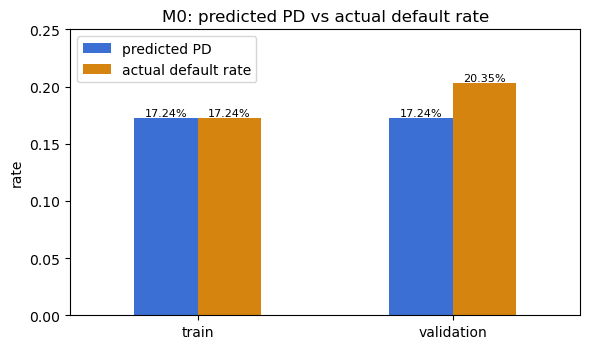

,predicted PD,actual default rate
train,0.1724,0.1724
validation,0.1724,0.2035


In [8]:
calib = pd.DataFrame({
    "predicted PD": [cards[s]["mean_pd"] for s in cards],
    "actual default rate": [cards[s]["default_rate"] for s in cards],
}, index=list(cards))
ax = calib.plot.bar(figsize=(6, 3.6), color=["#3b6fd4", "#d4840f"], rot=0)
ax.set_ylabel("rate"); ax.set_title("M0: predicted PD vs actual default rate")
for container in ax.containers:
    ax.bar_label(container, labels=[f"{v*100:.2f}%" for v in container.datavalues], fontsize=8)
ax.set_ylim(0, 0.25); plt.tight_layout()
plt.savefig(RESULTS / "m0_calibration.png", dpi=150); plt.show()
calib.round(4)

## 8. Approval-rate vs bad-rate curve
If the lender approves the safest X% of applicants (lowest PD), what share of them defaults? M0 can't tell applicants apart, so every approval rate gives the overall bad rate: a **flat line**. A useful model will bend this curve down on the left.

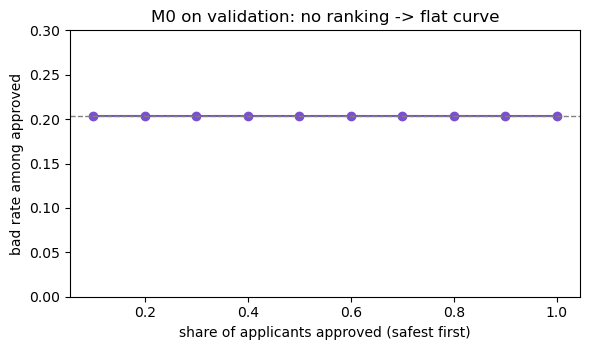

,approval_rate,approved,bad_rate_among_approved
0,0.1,16274,0.2035
1,0.2,32549,0.2035
2,0.3,48824,0.2035
3,0.4,65098,0.2035
4,0.5,81372,0.2035
5,0.6,97647,0.2035
6,0.7,113922,0.2035
7,0.8,130196,0.2035
8,0.9,146470,0.2035
9,1.0,162745,0.2035


In [9]:
curve = ev.approval_curve(y_val, pd_val)
ax = curve.plot(x="approval_rate", y="bad_rate_among_approved", marker="o", figsize=(6, 3.6),
                color="#7a4fd1", legend=False)
ax.axhline(y_val.mean(), ls="--", color="grey", lw=1)
ax.set_xlabel("share of applicants approved (safest first)")
ax.set_ylabel("bad rate among approved")
ax.set_title("M0 on validation: no ranking -> flat curve")
ax.set_ylim(0, 0.3); plt.tight_layout()
plt.savefig(RESULTS / "m0_approval_curve.png", dpi=150); plt.show()
curve.round(4)

## 9. Segments: 36- vs 60-month loans

In [10]:
segments = pd.concat([
    ev.segment_report(y_train, pd_train, X_train["term_months"], "term_months").assign(split="train"),
    ev.segment_report(y_val, pd_val, X_val["term_months"], "term_months").assign(split="validation"),
])
segments[["split", "term_months", "rows", "default_rate", "mean_pd", "calibration_gap", "roc_auc", "brier"]].round(4)

,split,term_months,rows,default_rate,mean_pd,calibration_gap,roc_auc,brier
0,train,36.0,287714,0.1319,0.1724,0.0405,0.5,0.1161
1,train,60.0,100410,0.2886,0.1724,-0.1162,0.5,0.2188
0,validation,36.0,120790,0.1512,0.1724,0.0212,0.5,0.1288
1,validation,60.0,41955,0.3540,0.1724,-0.1815,0.5,0.2616


60-month loans default far more often than 36-month loans, yet M0 gives both the same PD. Even one feature (`term_months`) would already beat M0. M1 will use all 190.

## 10. Version A vs B
Version B drops LendingClub's grade, sub_grade, int_rate and installment. M0 uses **no** features, so A and B are identical; the results are recorded once and apply to both.

## 11. Save results

In [11]:
joblib.dump(m0, RESULTS / "m0_dummy.joblib")
segments.to_csv(RESULTS / "m0_segment_metrics.csv", index=False)
curve.to_csv(RESULTS / "m0_approval_curve.csv", index=False)
summary = {
    "model": "M0", "name": "Dummy baseline", "estimator": "sklearn.dummy.DummyClassifier",
    "parameters": m0.get_params(), "learned_prior_default": float(m0.class_prior_[1]),
    "versions": "A and B identical (no features used)", "test_split": "sealed",
    "environment": {"python": platform.python_version(), "pandas": pd.__version__,
                    "scikit_learn": sklearn.__version__},
    "metrics": cards,
}
(RESULTS / "m0_metrics.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
for split, card in cards.items():
    for version in ("A", "B"):
        board = ev.update_leaderboard("M0", version, split, card, notes="constant PD = train default rate")
print("Saved:", sorted(p.name for p in RESULTS.iterdir()))
board.round(4)

Saved: ['m0_approval_curve.csv', 'm0_approval_curve.png', 'm0_calibration.png', 'm0_dummy.joblib', 'm0_metrics.json', 'm0_segment_metrics.csv']


,model,version,split,rows,default_rate,mean_pd,roc_auc,pr_auc,ks,brier,log_loss,calibration_gap,notes
0,M0,A,train,388124,0.1724,0.1724,0.5,0.1724,0.0,0.1427,0.4597,0.0000,constant PD = train default rate
1,M0,A,validation,162745,0.2035,0.1724,0.5,0.2035,0.0,0.1631,0.5085,-0.0311,constant PD = train default rate
2,M0,B,train,388124,0.1724,0.1724,0.5,0.1724,0.0,0.1427,0.4597,0.0000,constant PD = train default rate
3,M0,B,validation,162745,0.2035,0.1724,0.5,0.2035,0.0,0.1631,0.5085,-0.0311,constant PD = train default rate


## 12. Conclusion: the bar M1 must clear

In [12]:
v = cards["validation"]
print("On VALIDATION, M0 scores:")
print(f"  ROC-AUC {v['roc_auc']:.3f} | KS {v['ks']:.3f} | PR-AUC {v['pr_auc']:.3f} | "
      f"Brier {v['brier']:.4f} | log loss {v['log_loss']:.4f}")
print("\nM1 (Logistic Regression) must clearly beat these: above all ROC-AUC > 0.5 and a lower Brier / log loss.")
print(f"Calibration lesson: a constant {v['mean_pd']:.2%} under-predicts the real {v['default_rate']:.2%} by "
      f"{-v['calibration_gap']*100:.2f} points, so the final model must be calibrated on validation.")

On VALIDATION, M0 scores:
  ROC-AUC 0.500 | KS 0.000 | PR-AUC 0.204 | Brier 0.1631 | log loss 0.5085

M1 (Logistic Regression) must clearly beat these: above all ROC-AUC > 0.5 and a lower Brier / log loss.
Calibration lesson: a constant 17.24% under-predicts the real 20.35% by 3.11 points, so the final model must be calibrated on validation.
